In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("adult_with_headers.csv")
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


<Axes: xlabel='marital_status'>

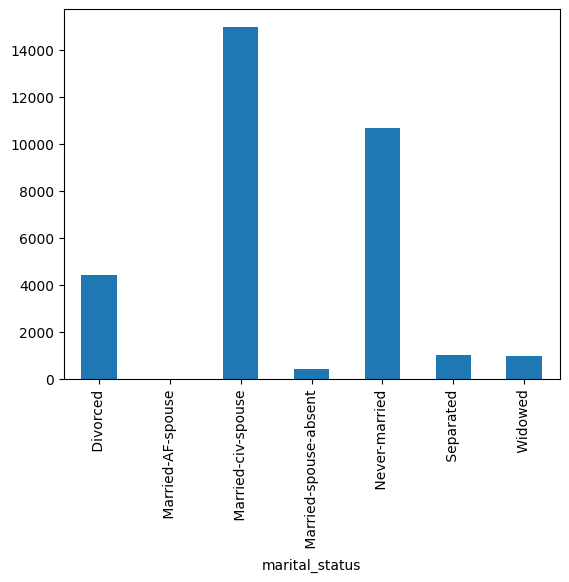

In [4]:
df.groupby('marital_status').size().plot(kind='bar')

<Axes: xlabel='occupation'>

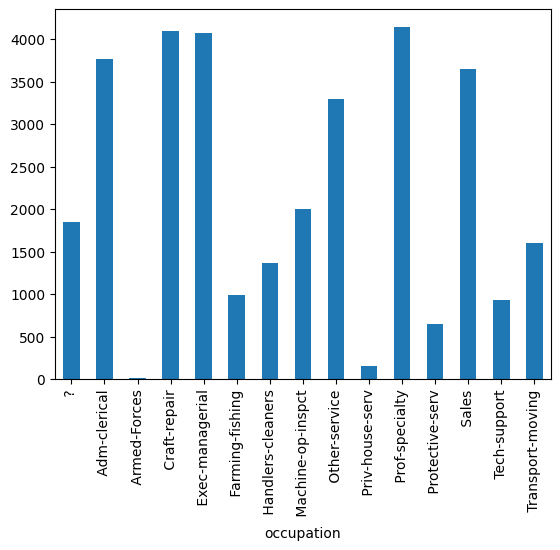

In [5]:
df.groupby('occupation').size().plot(kind='bar')

<Axes: xlabel='relationship'>

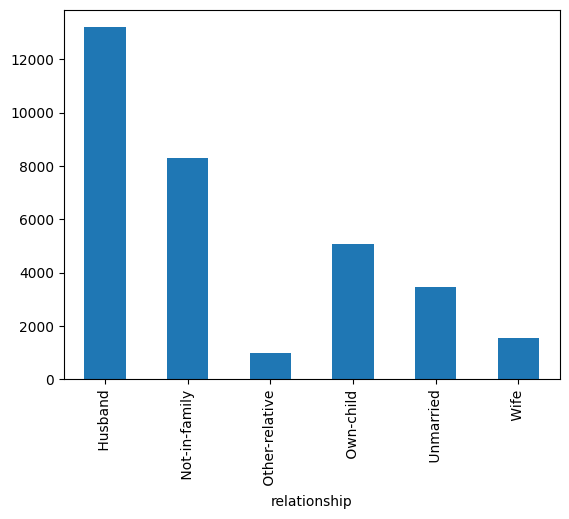

In [6]:
df.groupby('relationship').size().plot(kind='bar')

<Axes: xlabel='race'>

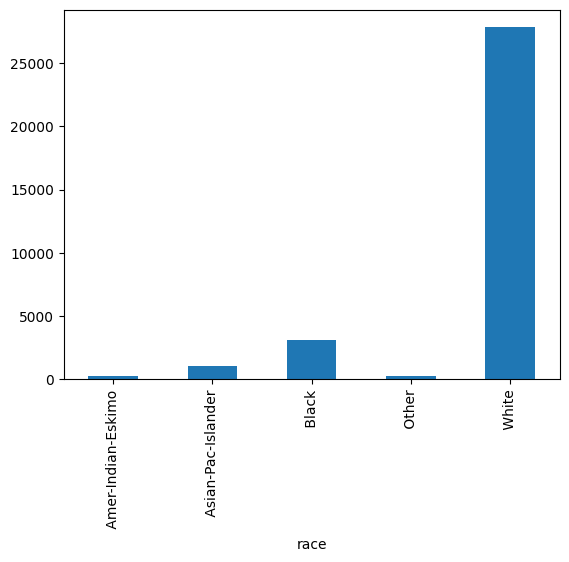

In [8]:
df.groupby('race').size().plot(kind='bar')

<Axes: xlabel='native_country'>

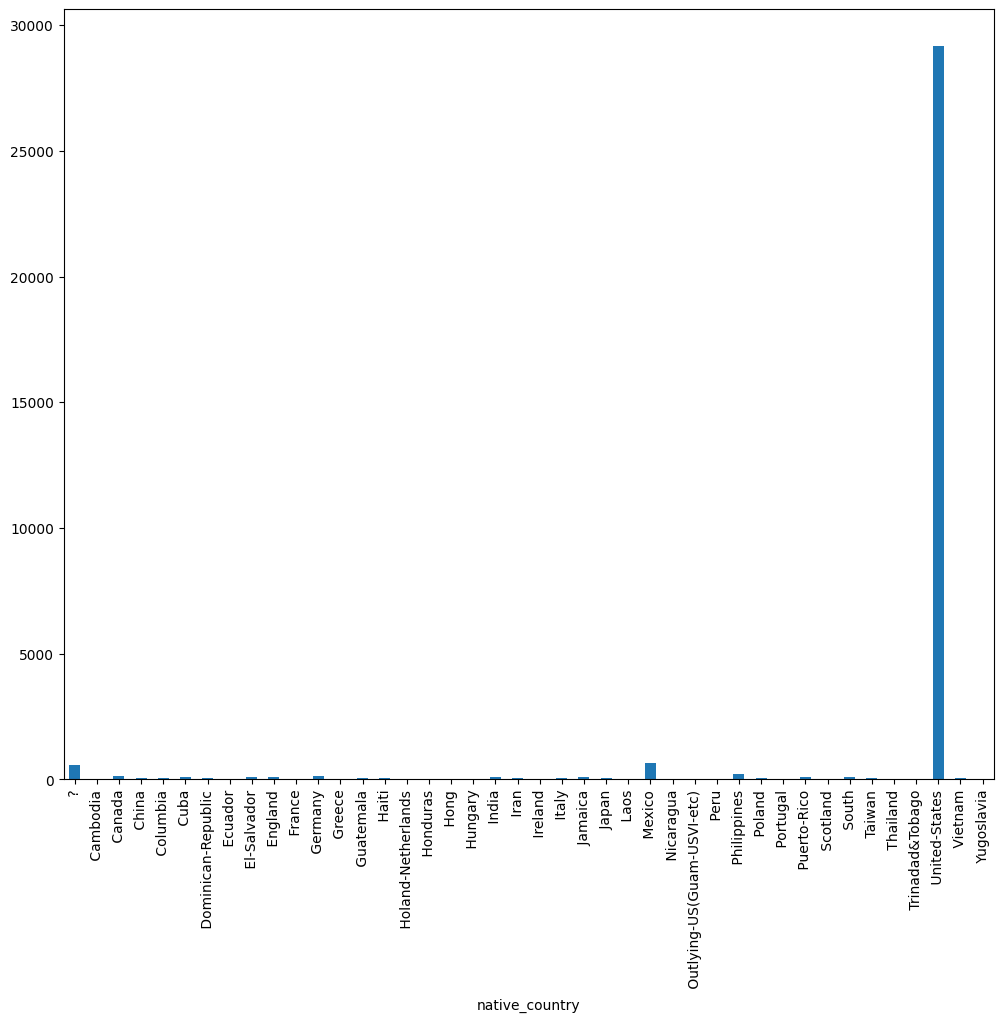

In [9]:
df.groupby('native_country').size().plot(kind='bar',figsize=(12,10))

<Axes: xlabel='workclass'>

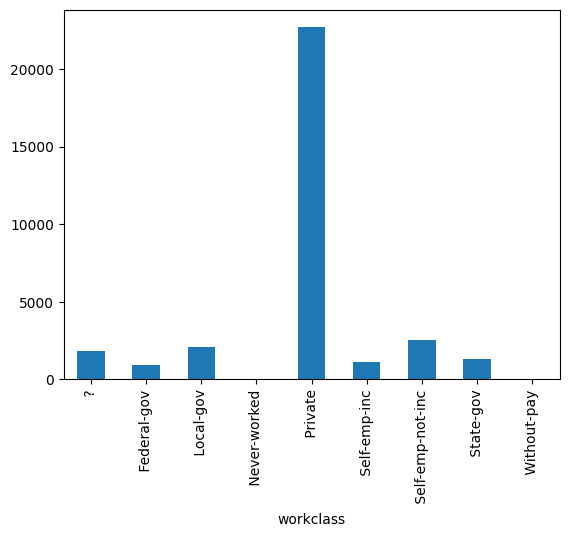

In [10]:
df.groupby('workclass').size().plot(kind='bar')

<Axes: >

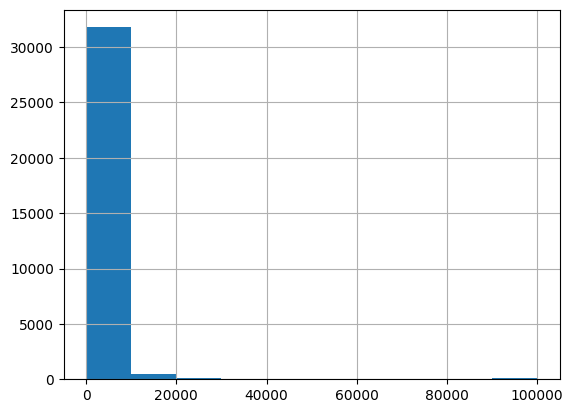

In [11]:
df["capital_gain"].hist()

<Axes: >

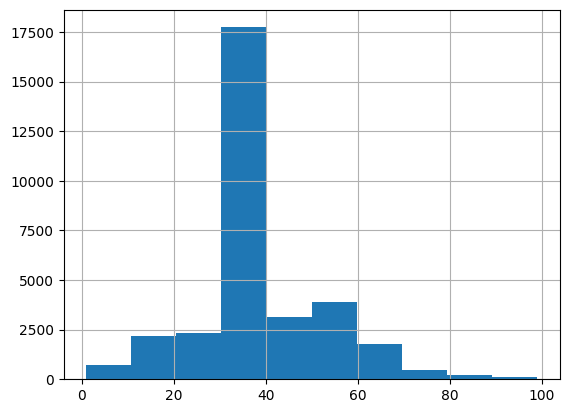

In [12]:
df["hours_per_week"].hist()

In [13]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education_num,int64
marital_status,object
occupation,object
relationship,object
race,object
sex,object


In [14]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [15]:
from scipy import stats

In [17]:
ENC_df=pd.get_dummies(df[["race"]],dtype='int')
ENC_df.head()

,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,1,0,0
4,0,0,1,0,0


In [18]:
df=df.iloc[:,0:15].join(ENC_df)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0,0,0,0,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0,0,0,0,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,0,0,0,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0,0,1,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,0,1,0,0


In [19]:
ENC_df1=pd.get_dummies(df[["sex"]],dtype='int')
ENC_df1.head()

,sex_ Female,sex_ Male
0,0,1
1,0,1
2,0,1
3,0,1
4,1,0


In [20]:
df=df.iloc[:,0:21].join(ENC_df1)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,hours_per_week,native_country,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,40,United-States,<=50K,0,0,0,0,1,0,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,13,United-States,<=50K,0,0,0,0,1,0,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,40,United-States,<=50K,0,0,0,0,1,0,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,40,United-States,<=50K,0,0,1,0,0,0,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,40,Cuba,<=50K,0,0,1,0,0,1,0


In [21]:
df=df.drop(["race","sex"],axis=1)
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,40,United-States,<=50K,0,0,0,0,1,0,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,13,United-States,<=50K,0,0,0,0,1,0,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,40,United-States,<=50K,0,0,0,0,1,0,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40,United-States,<=50K,0,0,1,0,0,0,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,40,Cuba,<=50K,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,0,0,38,United-States,<=50K,0,0,0,0,1,1,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,0,0,40,United-States,>50K,0,0,0,0,1,0,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,0,0,40,United-States,<=50K,0,0,0,0,1,1,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,0,0,20,United-States,<=50K,0,0,0,0,1,0,1


In [22]:
#Label encoding
from sklearn.preprocessing import LabelEncoder
df["workclass"] = LabelEncoder().fit_transform(df["workclass"])
df["education"] = LabelEncoder().fit_transform(df["education"])
df["marital_status"] = LabelEncoder().fit_transform(df["marital_status"])
df["occupation"] = LabelEncoder().fit_transform(df["occupation"])
df["relationship"] = LabelEncoder().fit_transform(df["relationship"])
df["native_country"] = LabelEncoder().fit_transform(df["native_country"])
df["income"] = LabelEncoder().fit_transform(df["income"])

In [23]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male
0,39,7,77516,9,13,4,1,1,2174,0,40,39,0,0,0,0,0,1,0,1
1,50,6,83311,9,13,2,4,0,0,0,13,39,0,0,0,0,0,1,0,1
2,38,4,215646,11,9,0,6,1,0,0,40,39,0,0,0,0,0,1,0,1
3,53,4,234721,1,7,2,6,0,0,0,40,39,0,0,0,1,0,0,0,1
4,28,4,338409,9,13,2,10,5,0,0,40,5,0,0,0,1,0,0,1,0


In [24]:
#Discuss the pros and cons of One-Hot Encoding and Label Encoding.

#One-Hot encoding:
    #  pros:
    #   1.No implied order- Treats all categories equally, avoiding any false ordinal relationships.
    #   2.Easy interpretation- Each column clearly represents a specific category.
    #  cons:
    #   1.Increased dimentionality.
    #   2.Risk of overfitting.

#Label encoding:
    #  pros:
    #   1.Compact representation- Uses only one feature column, reducing feature space.
    #   2.Memory efficient
    #  cons:
    #   1.Less interpretability- Numerical labels are harder to map directly to category values.
    #   2.Model bias

In [25]:
# Standard Scaling
from sklearn.preprocessing import StandardScaler
scaled_data_standard = StandardScaler().fit_transform(df)
scaled_data_standard

array([[ 0.03067056,  2.15057856, -1.06361075, ...,  0.4130197 ,
        -0.70307135,  0.70307135],
       [ 0.83710898,  1.46373585, -1.008707  , ...,  0.4130197 ,
        -0.70307135,  0.70307135],
       [-0.04264203,  0.09005041,  0.2450785 , ...,  0.4130197 ,
        -0.70307135,  0.70307135],
       ...,
       [ 1.42360965,  0.09005041, -0.35877741, ...,  0.4130197 ,
         1.42233076, -1.42233076],
       [-1.21564337,  0.09005041,  0.11095988, ...,  0.4130197 ,
        -0.70307135,  0.70307135],
       [ 0.98373415,  0.77689313,  0.92989258, ...,  0.4130197 ,
         1.42233076, -1.42233076]])

In [26]:
# Min-Max scaling
from sklearn.preprocessing import MinMaxScaler
scaled_data_minmax = MinMaxScaler().fit_transform(df)
scaled_data_minmax

array([[0.30136986, 0.875     , 0.0443019 , ..., 1.        , 0.        ,
        1.        ],
       [0.45205479, 0.75      , 0.0482376 , ..., 1.        , 0.        ,
        1.        ],
       [0.28767123, 0.5       , 0.13811345, ..., 1.        , 0.        ,
        1.        ],
       ...,
       [0.56164384, 0.5       , 0.09482688, ..., 1.        , 1.        ,
        0.        ],
       [0.06849315, 0.5       , 0.12849934, ..., 1.        , 0.        ,
        1.        ],
       [0.47945205, 0.625     , 0.18720338, ..., 1.        , 1.        ,
        0.        ]])

In [27]:
#Discuss the scenarios where each scaling technique is preferred and why?

# Standard scalling transforms data to have a mean of 0 and a std of 1.
# When the data is alreay approximately normally distributed, so standard scalling keeps the distribution shape but brings it to standard form.

#Min-Max scaling compresses the data into fixed range, usually it is best suited for the data with abounded range.

In [31]:
from numpy import set_printoptions
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
X = df[["age","workclass","fnlwgt","education","education_num","marital_status","occupation","relationship","capital_gain","capital_loss","hours_per_week","native_country","race_ Amer-Indian-Eskimo","race_ Asian-Pac-Islander","race_ Black","race_ Other","race_ White","sex_ Female","sex_ Male"]]
Y = df["income"]

In [32]:
# feature extraction
test = SelectKBest(score_func=chi2, k=4)
fit = test.fit(X, Y)

In [33]:
# summarize scores
set_printoptions(precision=3)
print(fit.scores_)

[8.601e+03 4.751e+01 1.711e+05 2.979e+02 2.401e+03 1.123e+03 5.046e+02
 3.659e+03 8.219e+07 1.372e+06 6.476e+03 1.362e+01 2.660e+01 3.504e+00
 2.336e+02 3.271e+01 3.446e+01 1.016e+03 5.024e+02]


In [34]:
features = fit.transform(X)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [36]:
# Feature extraction
model = LogisticRegression(max_iter=400)
rfe = RFE(model,n_features_to_select=2)
fit = rfe.fit(X, Y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [37]:
fit.ranking_

array([10, 13, 18, 12,  5,  6, 14,  7, 17, 16, 11, 15,  2,  8,  3,  1,  9,
        1,  4])

In [38]:
adult1 = np.log1p(df)

<Axes: ylabel='Count'>

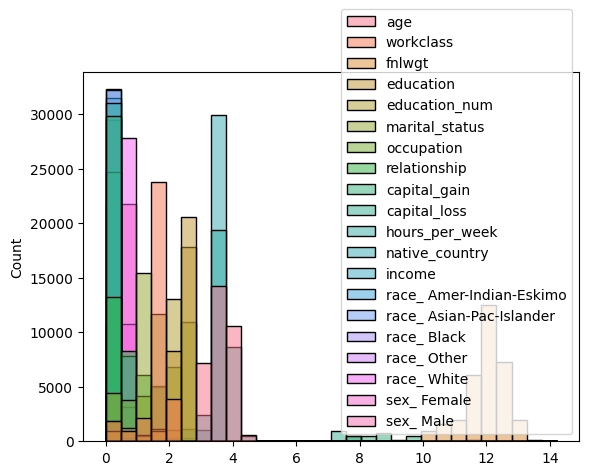

In [39]:
import seaborn as sns
sns.histplot(adult1, bins=30)

In [40]:
from sklearn.ensemble import IsolationForest

In [41]:
IF=IsolationForest(random_state=10,contamination=.01)
IF.fit(df)

IsolationForest(contamination=0.01, random_state=10)

In [42]:
# Predictions
outliers=IF.predict(df)
outliers

array([1, 1, 1, ..., 1, 1, 1])

In [43]:
df['scores']=IF.decision_function(df.iloc[:,0:20])

In [44]:
df['anomaly']=IF.predict(df.iloc[:,0:20])
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,scores,anomaly
0,39,7,77516,9,13,4,1,1,2174,0,...,0,0,0,0,0,1,0,1,0.146686,1
1,50,6,83311,9,13,2,4,0,0,0,...,0,0,0,0,0,1,0,1,0.168516,1
2,38,4,215646,11,9,0,6,1,0,0,...,0,0,0,0,0,1,0,1,0.207361,1
3,53,4,234721,1,7,2,6,0,0,0,...,0,0,0,1,0,0,0,1,0.083417,1
4,28,4,338409,9,13,2,10,5,0,0,...,0,0,0,1,0,0,1,0,0.015247,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,0,0,...,0,0,0,0,0,1,1,0,0.128435,1
32557,40,4,154374,11,9,2,7,0,0,0,...,1,0,0,0,0,1,0,1,0.216874,1
32558,58,4,151910,11,9,6,1,4,0,0,...,0,0,0,0,0,1,1,0,0.144136,1
32559,22,4,201490,11,9,4,1,3,0,0,...,0,0,0,0,0,1,0,1,0.192921,1


In [45]:
print("No.of outliers",len(df[df['anomaly']==-1]))
print("They are:")
df[df['anomaly']==-1]

No.of outliers 326
They are:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,scores,anomaly
52,47,4,51835,14,15,2,10,5,0,1902,...,1,0,0,0,0,1,1,0,-0.019456,-1
93,30,4,117747,11,9,2,12,5,0,1573,...,0,0,1,0,0,0,1,0,-0.026627,-1
157,71,6,494223,15,10,5,12,4,0,1816,...,0,0,0,1,0,0,0,1,-0.043142,-1
226,60,0,24215,0,6,0,0,1,0,0,...,0,1,0,0,0,0,1,0,-0.042973,-1
297,39,0,157443,12,14,2,0,5,3464,0,...,0,0,1,0,0,0,1,0,-0.029303,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32254,31,4,251659,15,10,2,8,0,0,1485,...,1,0,1,0,0,0,0,1,-0.031274,-1
32370,53,6,137547,14,15,4,10,1,27828,0,...,1,0,1,0,0,0,0,1,-0.012955,-1
32425,23,4,180771,3,2,2,7,5,0,0,...,0,1,0,0,0,0,1,0,-0.016405,-1
32508,45,4,155093,0,6,0,8,1,0,0,...,0,0,0,1,0,0,1,0,-0.005570,-1


In [46]:
#Discuss how outliers can affect model performance.

#Reducing the model accuracy and stability.
#Potential loss of valuable information.